In [164]:
%cd /Users/debasmitroy/Desktop/programming/research/debasmit-ut-research/ITML-quest/

/Users/debasmitroy/Desktop/programming/research/debasmit-ut-research/ITML-quest


## Dataset link: https://drive.google.com/file/d/1-KCSBeS_F5YobId2y11V7RWQGTsJcNIU/view?usp=sharing . Unzip to `data/` folder.

## Imports

In [165]:
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sentence_transformers import SentenceTransformer
from torchvision.models import ViT_B_16_Weights, vit_b_16
from tqdm import tqdm

# Configuration

In [77]:
DATA_ROOT = Path("data/caltech_101_low/train")
SEED = 42
TRAIN_PER_CLASS = 20
TEST_PER_CLASS = 5
IMAGE_BATCH_SIZE = 16
TEXT_BATCH_SIZE = 64
EXCLUDED_CLASSES = {"BACKGROUND_Google"}

## Utility

In [78]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

def l2_normalize(x, eps=1e-12):
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)

def clean_class_name(name):
    return name.replace("_", " ").strip().lower()

## Dataset

In [79]:
class CaltechSmallDataset:
    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

    def __init__(self, root, train_per_class=5, test_per_class=2, seed=42):
        self.root = Path(root)
        self.train_per_class = train_per_class
        self.test_per_class = test_per_class
        self.seed = seed
        self.class_names = []
        self.train_paths = []
        self.train_labels = []
        self.test_paths = []
        self.test_labels = []
        self._prepare()

    def _prepare(self):
        if not self.root.exists():
            raise FileNotFoundError(f"Dataset not found: {self.root.resolve()}")

        class_dirs = [
            p for p in sorted(self.root.iterdir())
            if p.is_dir() and p.name not in EXCLUDED_CLASSES
        ]

        rng = random.Random(self.seed)
        required = self.train_per_class + self.test_per_class

        for class_dir in class_dirs:
            files = [
                f for f in sorted(class_dir.iterdir())
                if f.is_file() and f.suffix.lower() in self.IMAGE_EXTENSIONS
            ]

            if len(files) < required:
                print(f"Skipping {class_dir.name}: only {len(files)} images")
                continue

            rng.shuffle(files)
            class_id = len(self.class_names)
            self.class_names.append(class_dir.name)

            train_files = files[:self.train_per_class]
            test_files = files[self.train_per_class:required]

            for path in train_files:
                self.train_paths.append(path)
                self.train_labels.append(class_id)

            for path in test_files:
                self.test_paths.append(path)
                self.test_labels.append(class_id)

        self.train_labels = np.asarray(self.train_labels)
        self.test_labels = np.asarray(self.test_labels)

        print(f"\nClasses: {len(self.class_names)}")
        print(f"CSA fitting images: {len(self.train_paths)}")
        print(f"Test images: {len(self.test_paths)}")

    def make_training_texts(self):
        templates = [
            "a photo of a {}",
            "an image of a {}",
            "a picture of a {}",
            "a photograph of a {}",
            "this is a photo of a {}",
        ]
        texts = []
        for i, class_id in enumerate(self.train_labels):
            name = clean_class_name(self.class_names[int(class_id)])
            texts.append(templates[i % len(templates)].format(name))
        return texts


In [80]:
def create_text_prototypes(class_names, text_encoder, csa):
    templates = [
        "a photo of a {}",
        "an image of a {}",
        "a picture of a {}",
        "a photograph of a {}",
        "this is an image of a {}",
    ]

    texts = []
    owners = []

    for class_id, class_name in enumerate(class_names):
        name = clean_class_name(class_name)
        for template in templates:
            texts.append(template.format(name))
            owners.append(class_id)

    text_features = text_encoder.encode(texts)
    text_canonical = csa.transform_texts(text_features)
    owners = np.asarray(owners)

    prototypes = [
        text_canonical[owners == class_id].mean(axis=0)
        for class_id in range(len(class_names))
    ]
    return np.stack(prototypes)


## Image Encoder

In [166]:
from torchvision import transforms

class ViTImageEncoder:
    def __init__(self, device, batch_size=16):
        self.device = device
        self.batch_size = batch_size

        weights = ViT_B_16_Weights.DEFAULT
        self.preprocess = weights.transforms()

        # Augmentation pipeline
        self.augment_transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.model = vit_b_16(weights=weights)
        self.model.heads = torch.nn.Identity()

        self.model.eval().to(device)

        for p in self.model.parameters():
            p.requires_grad_(False)

        self.output_dim = 768

    @torch.inference_mode()
    def encode(self, image_paths, augment=False):
        all_features = []

        for start in tqdm(
            range(0, len(image_paths), self.batch_size),
            desc=f"Encoding images | augment={augment}"
        ):
            batch_paths = image_paths[
                start:start + self.batch_size
            ]

            images = []

            for path in batch_paths:
                image = Image.open(path).convert("RGB")

                if augment:
                    image = self.augment_transform(image)
                else:
                    image = self.preprocess(image)

                images.append(image)

            batch = torch.stack(images).to(self.device)

            features = self.model(batch).cpu().numpy()
            all_features.append(features)

        features = np.concatenate(
            all_features,
            axis=0
        ).astype(np.float64)

        return l2_normalize(features)

## Text Encoder

In [82]:
class MiniLMTextEncoder:
    def __init__(
        self,
        device,
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        batch_size=64
    ):
        self.batch_size = batch_size
        self.model = SentenceTransformer(model_name, device=device)

    def encode(self, texts):
        features = self.model.encode(
            list(texts),
            batch_size=self.batch_size,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True
        )
        return features.astype(np.float64)



## CSA

In [253]:
@dataclass
class CSAConfig:
    regularization: float = 1e-3
    max_components: int = 64
    correlation_threshold: float = 0.20
    s: Optional[int] = None

class CSA:
    def __init__(self, config):
        self.config = config
        self.image_mean = None
        self.text_mean = None
        self.A = None
        self.B = None
        self.rho = None
        self.s = None

    @staticmethod
    def inverse_sqrt_psd(matrix, eps=1e-10):
        values, vectors = np.linalg.eigh(matrix)
        values = np.clip(values, eps, None)
        return vectors @ np.diag(1.0 / np.sqrt(values)) @ vectors.T

    def fit(self, image_features, text_features):
        if image_features.shape[0] != text_features.shape[0]:
            raise ValueError("Image and text feature counts must match.")

        N = image_features.shape[0]
        self.image_mean = image_features.mean(axis=0, keepdims=True)
        self.text_mean = text_features.mean(axis=0, keepdims=True)

        X = image_features - self.image_mean
        Y = text_features - self.text_mean

        Cxx = (X.T @ X) / (N - 1)
        Cyy = (Y.T @ Y) / (N - 1)
        Cxy = (X.T @ Y) / (N - 1)

        reg = self.config.regularization
        Cxx += reg * np.eye(Cxx.shape[0])
        Cyy += reg * np.eye(Cyy.shape[0])

        Wx = self.inverse_sqrt_psd(Cxx)
        Wy = self.inverse_sqrt_psd(Cyy)

        P = Wx @ Cxy @ Wy
        U, singular_values, Vt = np.linalg.svd(P, full_matrices=False)

        r = min(
            self.config.max_components,
            N - 1,
            image_features.shape[1],
            text_features.shape[1]
        )

        U = U[:, :r]
        V = Vt.T[:, :r]

        self.A = Wx @ U
        self.B = Wy @ V
        self.rho = np.clip(singular_values[:r], 0.0, 1.0)

        if self.config.s is not None:
            self.s = int(np.clip(self.config.s, 1, r))
        else:
            self.s = max(1, int(np.sum(
                self.rho >= self.config.correlation_threshold
            )))

        print(f"\nCSA fitted on {N} pairs")
        print(f"Canonical rank: {r}")
        print(f"Selected s: {self.s}")
        print("First 10 rho:", np.round(self.rho[:10], 4))
        return self

    def transform_images(self, features):
        return (features - self.image_mean) @ self.A

    def transform_texts(self, features):
        return (features - self.text_mean) @ self.B

    def similarity_matrix(self, image_canonical, text_canonical, s=None):
        s = self.s if s is None else min(int(s), len(self.rho))
        X = l2_normalize(image_canonical[:, :s])
        Y = l2_normalize(text_canonical[:, :s])
        return (X * self.rho[:s][None, :]) @ Y.T

    def paired_similarity(self, image_features, text_features, s=None):
        s = self.s if s is None else min(int(s), len(self.rho))
        X = l2_normalize(self.transform_images(image_features)[:, :s])
        Y = l2_normalize(self.transform_texts(text_features)[:, :s])
        return np.sum(X * Y * self.rho[:s][None, :], axis=1)
    
    def same_modality_canonical_similarity(
        self,
        features1,
        features2,
        modality,
        s=None,
        paired=True
    ):
        s = self.s if s is None else min(int(s), len(self.rho))

        if modality == "image":
            X = self.transform_images(features1)[:, :s]
            Y = self.transform_images(features2)[:, :s]

        elif modality == "text":
            X = self.transform_texts(features1)[:, :s]
            Y = self.transform_texts(features2)[:, :s]

        else:
            raise ValueError("modality must be 'image' or 'text'")

        X = l2_normalize(X)
        Y = l2_normalize(Y)

        if paired:
            return np.sum(X * Y, axis=1)

        return X @ Y.T

## Evaluation

In [179]:
def evaluate_classification(similarity, labels):
    pred = np.argmax(similarity, axis=1)
    top1 = np.mean(pred == labels)

    top5_idx = np.argsort(similarity, axis=1)[:, -5:]
    top5 = np.mean([
        label in guesses
        for label, guesses in zip(labels, top5_idx)
    ])
    return float(top1), float(top5)

def evaluate_matched_vs_shuffled(csa, image_features, text_features):
    matched = csa.paired_similarity(image_features, text_features)

    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(text_features))
    perm = np.roll(perm, 1)

    shuffled = csa.paired_similarity(
        image_features,
        text_features[perm]
    )
    return matched, shuffled

In [180]:
def plot_rho(rho, selected_s):
    x = np.arange(1, len(rho) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(x, rho, marker="o")
    plt.axvline(selected_s, linestyle="--", label=f"s={selected_s}")
    plt.xlabel("Canonical dimension")
    plt.ylabel(r"$\rho_i$")
    plt.title("CSA Canonical Correlations")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_matched_vs_shuffled(matched, shuffled):
    plt.figure(figsize=(7, 4))
    plt.hist(matched, bins=30, alpha=0.5, label="Matched", range=(-1, 1))
    plt.hist(shuffled, bins=30, alpha=0.5, label="Shuffled", range=(-1, 1))
    plt.xlabel("CSA similarity")
    plt.ylabel("Count")
    plt.title("Matched vs Shuffled Pairs")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Trigger

In [181]:
seed_everything(SEED)
device = get_device()
print(f"Device: {device}")

Device: mps


In [182]:
dataset = CaltechSmallDataset(
        DATA_ROOT,
        train_per_class=TRAIN_PER_CLASS,
        test_per_class=TEST_PER_CLASS,
        seed=SEED
    )


Skipping inline_skate: only 24 images

Classes: 100
CSA fitting images: 2000
Test images: 500


In [184]:
train_texts = dataset.make_training_texts()

In [187]:
# dataset.train_paths

In [89]:
print(f"Training texts: {len(train_texts)}")
print(f"Training images: {len(dataset.train_paths)}")
print(f"Test images: {len(dataset.test_paths)}")
print(f"Classes: {len(dataset.class_names)}")
print(f"First 5 training texts: {train_texts[:5]}")

Training texts: 2000
Training images: 2000
Test images: 500
Classes: 100
First 5 training texts: ['a photo of a faces', 'an image of a faces', 'a picture of a faces', 'a photograph of a faces', 'this is a photo of a faces']


In [254]:
image_encoder = ViTImageEncoder(
        device=device,
        batch_size=IMAGE_BATCH_SIZE
    )
text_encoder = MiniLMTextEncoder(
    device=device,
    batch_size=TEXT_BATCH_SIZE
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9282.03it/s]


In [189]:
print("\nEncoding CSA fitting images...")
image_train_features = image_encoder.encode(dataset.train_paths)


Encoding CSA fitting images...


Encoding images | augment=False: 100%|██████████| 125/125 [00:34<00:00,  3.59it/s]


In [190]:
print("\nEncoding CSA fitting text...")
text_train_features = text_encoder.encode(train_texts)


Encoding CSA fitting text...


Batches: 100%|██████████| 32/32 [00:00<00:00, 58.31it/s]


In [191]:
print("\nFeature shapes")
print("Image:", image_train_features.shape)
print("Text :", text_train_features.shape)


Feature shapes
Image: (2000, 768)
Text : (2000, 384)


In [192]:
csa = CSA(CSAConfig(
        regularization=1e-3,
        max_components=min(image_train_features.shape[0], text_train_features.shape[0]),
        correlation_threshold=0.0090,
        s=None
    ))
csa.fit(image_train_features, text_train_features)


CSA fitted on 2000 pairs
Canonical rank: 384
Selected s: 299
First 10 rho: [0.9061 0.8806 0.8655 0.861  0.8552 0.85   0.846  0.841  0.8345 0.8314]


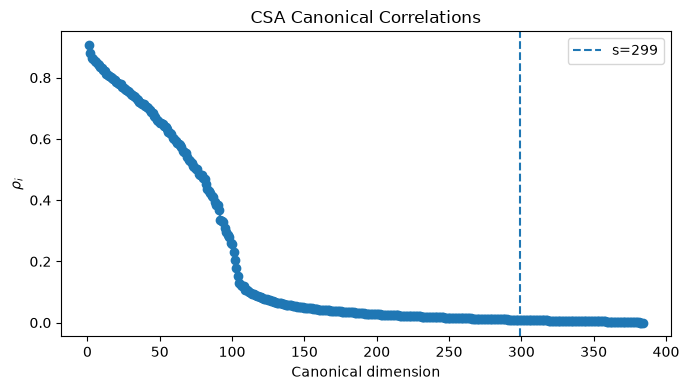

In [193]:
plot_rho(csa.rho, csa.s)


Matched mean : 0.3957
Shuffled mean: -0.001


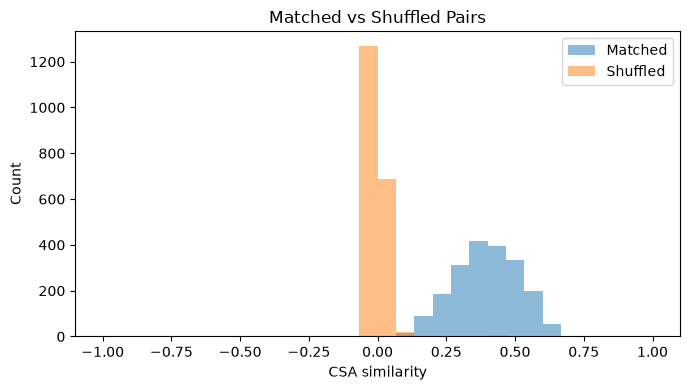

In [194]:
matched, shuffled = evaluate_matched_vs_shuffled(
        csa,
        image_train_features,
        text_train_features
    )

print("\nMatched mean :", round(float(matched.mean()), 4))
print("Shuffled mean:", round(float(shuffled.mean()), 4))
plot_matched_vs_shuffled(matched, shuffled)

In [195]:
print("\nEncoding test images...")
image_test_features = image_encoder.encode(dataset.test_paths)
image_test_canonical = csa.transform_images(image_test_features)


Encoding test images...


Encoding images | augment=False: 100%|██████████| 32/32 [00:10<00:00,  3.07it/s]


In [196]:
print("\nCreating class text prototypes...")
class_text_canonical = create_text_prototypes(
    dataset.class_names,
    text_encoder,
    csa
)


Creating class text prototypes...


Batches: 100%|██████████| 8/8 [00:00<00:00, 55.99it/s]


In [197]:
scores = csa.similarity_matrix(
        image_test_canonical,
        class_text_canonical
    )

In [198]:
top1, top5 = evaluate_classification(
        scores,
        dataset.test_labels
    )

In [199]:
print("\n===== CALTECH-101 CSA RESULTS =====")
print(f"Classes: {len(dataset.class_names)}")
print(f"CSA fitting pairs: {len(dataset.train_paths)}")
print(f"Test images: {len(dataset.test_paths)}")
print(f"Selected s: {csa.s}")
print(f"Top-1 accuracy: {top1 * 100:.2f}%")
print(f"Top-5 accuracy: {top5 * 100:.2f}%")


===== CALTECH-101 CSA RESULTS =====
Classes: 100
CSA fitting pairs: 2000
Test images: 500
Selected s: 299
Top-1 accuracy: 91.60%
Top-5 accuracy: 99.40%



Sensitivity to s
s= 1 | Top-1=  2.00% | Top-5=  9.20%
s= 2 | Top-1= 12.20% | Top-5= 42.20%
s= 4 | Top-1= 42.60% | Top-5= 77.20%
s= 8 | Top-1= 67.20% | Top-5= 91.60%
s=16 | Top-1= 79.80% | Top-5= 95.60%
s=32 | Top-1= 86.60% | Top-5= 97.00%
s=64 | Top-1= 89.60% | Top-5= 98.00%


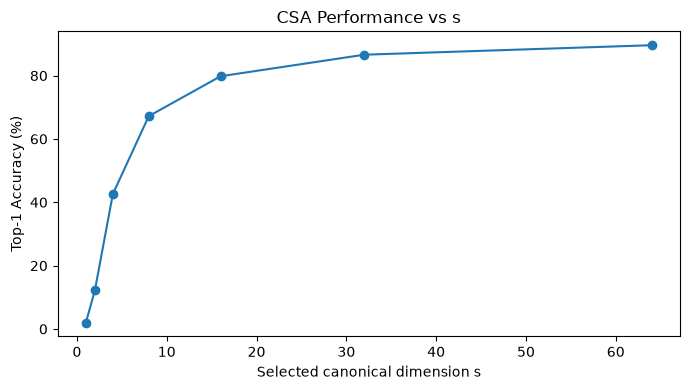

In [200]:
print("\nSensitivity to s")
candidate_s = [1, 2, 4, 8, 16, 32, 64]
candidate_s = [s for s in candidate_s if s <= len(csa.rho)]

s_values = []
accuracies = []

for s in candidate_s:
    scores_s = csa.similarity_matrix(
        image_test_canonical,
        class_text_canonical,
        s=s
    )
    top1_s, top5_s = evaluate_classification(
        scores_s,
        dataset.test_labels
    )
    s_values.append(s)
    accuracies.append(top1_s)

    print(
        f"s={s:2d} | "
        f"Top-1={top1_s * 100:6.2f}% | "
        f"Top-5={top5_s * 100:6.2f}%"
    )

plt.figure(figsize=(7, 4))
plt.plot(s_values, np.asarray(accuracies) * 100, marker="o")
plt.xlabel("Selected canonical dimension s")
plt.ylabel("Top-1 Accuracy (%)")
plt.title("CSA Performance vs s")
plt.tight_layout()
plt.show()

predictions = np.argmax(scores, axis=1)

In [201]:
print("\nExample predictions")
for i in range(min(20, len(dataset.test_paths))):
    true_id = int(dataset.test_labels[i])
    pred_id = int(predictions[i])

    print(
        f"{dataset.test_paths[i].name:18s} | "
        f"true={dataset.class_names[true_id]:18s} | "
        f"pred={dataset.class_names[pred_id]}"
    )


Example predictions
image_0187.jpg     | true=Faces              | pred=Faces_easy
image_0411.jpg     | true=Faces              | pred=Faces_easy
image_0198.jpg     | true=Faces              | pred=Faces_easy
image_0068.jpg     | true=Faces              | pred=Faces
image_0082.jpg     | true=Faces              | pred=Faces_easy
image_0325.jpg     | true=Faces_easy         | pred=Faces_easy
image_0393.jpg     | true=Faces_easy         | pred=Faces_easy
image_0007.jpg     | true=Faces_easy         | pred=Faces_easy
image_0180.jpg     | true=Faces_easy         | pred=Faces_easy
image_0112.jpg     | true=Faces_easy         | pred=Faces
image_0098.jpg     | true=Leopards           | pred=Leopards
image_0049.jpg     | true=Leopards           | pred=Leopards
image_0145.jpg     | true=Leopards           | pred=Leopards
image_0065.jpg     | true=Leopards           | pred=Leopards
image_0182.jpg     | true=Leopards           | pred=Leopards
image_0619.jpg     | true=Motorbikes         | pred=Mo

## Miniature Example

In [203]:
sample_text = "a photo of a butterfly"
sample_image_path = "data/caltech_101_low/train/butterfly/image_0013.jpg"

sample_text_features = text_encoder.encode([sample_text])
sample_image_features = image_encoder.encode([sample_image_path])

sample_image_canonical = csa.transform_images(sample_image_features)
sample_text_canonical = csa.transform_texts(sample_text_features)

sample_image_text_similarity = csa.paired_similarity(
    sample_image_features,
    sample_text_features
)

print("\nMiniature Example")
print(f"Sample text: {sample_text}")
print(f"Sample image: {sample_image_path}")
print(f"Sample text features shape: {sample_text_features.shape}")
print(f"Sample image features shape: {sample_image_features.shape}")
print(f"Sample image canonical shape: {sample_image_canonical.shape}")
print(f"Sample text canonical shape: {sample_text_canonical.shape}")
print(f"Sample image-text similarity: {sample_image_text_similarity[0]:.4f}")

Batches: 100%|██████████| 1/1 [00:00<00:00,  7.93it/s]
Encoding images | augment=False: 100%|██████████| 1/1 [00:00<00:00, 26.27it/s]


Miniature Example
Sample text: a photo of a butterfly
Sample image: data/caltech_101_low/train/butterfly/image_0013.jpg
Sample text features shape: (1, 384)
Sample image features shape: (1, 768)
Sample image canonical shape: (1, 384)
Sample text canonical shape: (1, 384)
Sample image-text similarity: 0.3060


## Adavanced Analysis

In [216]:
from pathlib import Path
from collections import defaultdict
import random


def derive_complement_paths(
    train_paths,
    max_per_class=10,
    seed=42
):
    """
    For every training image, assign a different image from the SAME class
    that was not included in train_paths.

    At most `max_per_class` unique complement images are used per class.

    Returns
    -------
    complement_paths : list[str]

        Same length and same class ordering as train_paths.

    Example
    -------
    train:
        Faces/image_0181.jpg
        Faces/image_0177.jpg
        ibis/image_0020.jpg

    complement:
        Faces/image_0001.jpg
        Faces/image_0002.jpg
        ibis/image_0004.jpg
    """

    rng = random.Random(seed)

    # ------------------------------------------------------------
    # Group original training images by class
    # ------------------------------------------------------------

    train_by_class = defaultdict(list)

    for path in train_paths:
        path = Path(path)

        class_name = path.parent.name

        train_by_class[class_name].append(
            path
        )

    # ------------------------------------------------------------
    # Find non-training images for every class
    # ------------------------------------------------------------

    complement_by_class = {}

    valid_extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp"
    }

    for class_name, class_train_paths in train_by_class.items():

        class_dir = class_train_paths[0].parent

        # Absolute/resolved set makes comparison safer
        train_set = {
            p.resolve()
            for p in class_train_paths
        }

        candidates = [
            p
            for p in sorted(class_dir.iterdir())
            if (
                p.is_file()
                and
                p.suffix.lower() in valid_extensions
                and
                p.resolve() not in train_set
            )
        ]

        if len(candidates) == 0:
            raise ValueError(
                f"No complement images available for class: {class_name}"
            )

        rng.shuffle(candidates)

        # At most 10 unique complement images per class
        candidates = candidates[
            :max_per_class
        ]

        complement_by_class[
            class_name
        ] = candidates

        print(
            f"{class_name:25s} | "
            f"train={len(class_train_paths):3d} | "
            f"complement pool={len(candidates):2d}"
        )

    # ------------------------------------------------------------
    # Build a complement list aligned with train_paths
    # ------------------------------------------------------------

    class_counter = defaultdict(int)

    complement_paths = []

    for train_path in train_paths:

        train_path = Path(train_path)

        class_name = (
            train_path.parent.name
        )

        candidates = (
            complement_by_class[
                class_name
            ]
        )

        index = (
            class_counter[class_name]
            %
            len(candidates)
        )

        complement_path = (
            candidates[index]
        )

        complement_paths.append(
            str(complement_path)
        )

        class_counter[class_name] += 1

    return complement_paths

In [255]:
def compute_variant_cross_similarities(
    csa,
    image_encoder,
    text_encoder,
    train_paths_file="train_paths.txt",
    text_original_file="train_texts.txt",
    text_sim_file="train_texts_sim.txt",
    text_extreme_file="train_texts_extreme.txt",
    text_shuffled_file="train_texts_shuff.txt",
    s_values=(1, 2, 4, 8, 16, 32, 64, 128, 256),
    max_complement_per_class=10,
    seed=42,
    negative=False,
):
    from pathlib import Path
    from collections import defaultdict
    import random

    def load_lines(path):
        with open(path, "r", encoding="utf-8") as f:
            return [line.strip() for line in f if line.strip()]

    def derive_complement_paths(train_paths, max_per_class=10, seed=42):
        rng = random.Random(seed)
        train_by_class = defaultdict(list)

        for path in train_paths:
            p = Path(path)
            train_by_class[p.parent.name].append(p)

        complement_by_class = {}
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}

        for class_name, class_train_paths in train_by_class.items():
            class_dir = class_train_paths[0].parent
            train_set = {p.resolve() for p in class_train_paths}

            candidates = [
                p for p in sorted(class_dir.iterdir())
                if (
                    p.is_file()
                    and p.suffix.lower() in valid_exts
                    and p.resolve() not in train_set
                )
            ]

            if len(candidates) == 0:
                raise ValueError(
                    f"No complement images available for class: {class_name}"
                )

            rng.shuffle(candidates)
            complement_by_class[class_name] = candidates[:max_per_class]

        counters = defaultdict(int)
        complement_paths = []

        for path in train_paths:
            p = Path(path)
            class_name = p.parent.name
            candidates = complement_by_class[class_name]

            idx = counters[class_name] % len(candidates)
            complement_paths.append(str(candidates[idx]))
            counters[class_name] += 1

        return complement_paths

    def maybe_shuffle(X, permutation):
        return X[permutation] if negative else X

    # ------------------------------------------------------------
    # 1. Load data
    # ------------------------------------------------------------

    train_paths = load_lines(train_paths_file)

    texts_original = load_lines(text_original_file)
    texts_similar = load_lines(text_sim_file)
    texts_extreme = load_lines(text_extreme_file)
    texts_shuffled = load_lines(text_shuffled_file)

    N = len(train_paths)

    complement_paths = derive_complement_paths(
        train_paths,
        max_per_class=max_complement_per_class,
        seed=seed
    )

    text_lists = {
        "text_original": texts_original,
        "text_similar": texts_similar,
        "text_extreme": texts_extreme,
        "text_shuffled": texts_shuffled,
    }

    for name, values in text_lists.items():
        if len(values) != N:
            raise ValueError(
                f"{name} has {len(values)} entries, "
                f"but train_paths has {N}"
            )

    print(f"\nTotal samples: {N}")
    print(f"negative={negative}")

    # ------------------------------------------------------------
    # 2. Encode image variants
    # ------------------------------------------------------------

    print("\nEncoding original images...")
    img_original = image_encoder.encode(
        train_paths,
        augment=False
    )

    print("\nEncoding augmented images...")
    img_augmented = image_encoder.encode(
        train_paths,
        augment=True
    )

    print("\nEncoding complement images...")
    img_complement = image_encoder.encode(
        complement_paths,
        augment=False
    )

    # ------------------------------------------------------------
    # 3. Encode text variants
    # ------------------------------------------------------------

    print("\nEncoding original text...")
    txt_original = text_encoder.encode(
        texts_original
    )

    print("\nEncoding similar text...")
    txt_similar = text_encoder.encode(
        texts_similar
    )

    print("\nEncoding extreme text...")
    txt_extreme = text_encoder.encode(
        texts_extreme
    )

    print("\nEncoding shuffled text...")
    txt_shuffled = text_encoder.encode(
        texts_shuffled
    )

    # ------------------------------------------------------------
    # 4. Feature dictionaries
    # ------------------------------------------------------------

    image_features = {
        "image_original": img_original,
        "image_augmented": img_augmented,
        "image_complement": img_complement,
    }

    text_features = {
        "text_original": txt_original,
        "text_similar": txt_similar,
        "text_extreme": txt_extreme,
        "text_shuffled": txt_shuffled,
    }

    image_labels = list(image_features.keys())
    text_labels = list(text_features.keys())

    # ------------------------------------------------------------
    # 5. Project once into full CSA space
    # ------------------------------------------------------------

    image_canonical = {
        name: csa.transform_images(features)
        for name, features in image_features.items()
    }

    text_canonical = {
        name: csa.transform_texts(features)
        for name, features in text_features.items()
    }

    # ------------------------------------------------------------
    # 6. One fixed permutation for negative comparison
    # ------------------------------------------------------------

    rng = np.random.default_rng(seed)
    permutation = rng.permutation(N)

    if negative and np.any(permutation == np.arange(N)):
        permutation = np.roll(permutation, 1)

    # ------------------------------------------------------------
    # 7. Compute all blocks for every s
    # ------------------------------------------------------------

    results = {}

    for s in s_values:
        if s > len(csa.rho):
            continue

        # ========================================================
        # Image <-> Image
        # cosine in first s CSA image dimensions
        # ========================================================

        image_cosine_matrix = np.zeros(
            (len(image_labels), len(image_labels)),
            dtype=np.float64
        )

        image_cosine_raw = {}

        for i, name1 in enumerate(image_labels):
            for j, name2 in enumerate(image_labels):

                X = image_canonical[name1][:, :s]
                Y = image_canonical[name2]

                Y = maybe_shuffle(
                    Y,
                    permutation
                )[:, :s]

                X = l2_normalize(X)
                Y = l2_normalize(Y)

                scores = np.sum(
                    X * Y,
                    axis=1
                )

                image_cosine_matrix[i, j] = scores.mean()

                image_cosine_raw[
                    (name1, name2)
                ] = scores

        # ========================================================
        # Text <-> Text
        # cosine in first s CSA text dimensions
        # ========================================================

        text_cosine_matrix = np.zeros(
            (len(text_labels), len(text_labels)),
            dtype=np.float64
        )

        text_cosine_raw = {}

        for i, name1 in enumerate(text_labels):
            for j, name2 in enumerate(text_labels):

                X = text_canonical[name1][:, :s]
                Y = text_canonical[name2]

                Y = maybe_shuffle(
                    Y,
                    permutation
                )[:, :s]

                X = l2_normalize(X)
                Y = l2_normalize(Y)

                scores = np.sum(
                    X * Y,
                    axis=1
                )

                text_cosine_matrix[i, j] = scores.mean()

                text_cosine_raw[
                    (name1, name2)
                ] = scores

        # ========================================================
        # Image <-> Text
        # CSA weighted similarity
        # ========================================================

        csa_matrix = np.zeros(
            (len(image_labels), len(text_labels)),
            dtype=np.float64
        )

        csa_raw = {}

        for i, image_name in enumerate(image_labels):
            for j, text_name in enumerate(text_labels):

                X = image_canonical[
                    image_name
                ][:, :s]

                Y = text_canonical[
                    text_name
                ]

                Y = maybe_shuffle(
                    Y,
                    permutation
                )[:, :s]

                X = l2_normalize(X)
                Y = l2_normalize(Y)

                scores = np.sum(
                    X
                    * Y
                    * csa.rho[:s][None, :],
                    axis=1
                )

                csa_matrix[i, j] = scores.mean()

                csa_raw[
                    (image_name, text_name)
                ] = scores

        # ========================================================
        # Store
        # ========================================================

        results[s] = {
            "csa_matrix": csa_matrix,
            "csa_raw": csa_raw,

            "image_cosine_matrix":
                image_cosine_matrix,

            "image_cosine_raw":
                image_cosine_raw,

            "text_cosine_matrix":
                text_cosine_matrix,

            "text_cosine_raw":
                text_cosine_raw,

            "image_labels":
                image_labels.copy(),

            "text_labels":
                text_labels.copy(),

            "negative":
                negative,

            "permutation":
                permutation.copy(),

            "train_paths":
                train_paths,

            "complement_paths":
                complement_paths,
        }

    return results

In [256]:
def plot_variant_cross_similarities(results, s):
    if s not in results:
        raise ValueError(
            f"s={s} not found. Available: {sorted(results.keys())}"
        )

    result = results[s]

    image_labels = result["image_labels"]
    text_labels = result["text_labels"]

    image_cosine = result["image_cosine_matrix"]   # 3 x 3
    text_cosine = result["text_cosine_matrix"]     # 4 x 4
    csa_matrix = result["csa_matrix"]              # 3 x 4

    # ------------------------------------------------------------
    # Build full (Image + Text) x (Image + Text) matrix
    # ------------------------------------------------------------

    top = np.concatenate(
        [
            image_cosine,
            csa_matrix
        ],
        axis=1
    )

    bottom = np.concatenate(
        [
            csa_matrix.T,
            text_cosine
        ],
        axis=1
    )

    full_matrix = np.concatenate(
        [
            top,
            bottom
        ],
        axis=0
    )

    labels = image_labels + text_labels

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    plt.figure(figsize=(10, 8))

    im = plt.imshow(
        full_matrix,
        aspect="auto",
        vmin=-1.0,
        vmax=1.0
    )

    plt.colorbar(
        im,
        label="Similarity"
    )

    plt.xticks(
        np.arange(len(labels)),
        labels,
        rotation=35,
        ha="right"
    )

    plt.yticks(
        np.arange(len(labels)),
        labels
    )

    # Write values
    for i in range(full_matrix.shape[0]):
        for j in range(full_matrix.shape[1]):

            plt.text(
                j,
                i,
                f"{full_matrix[i, j]:.3f}",
                ha="center",
                va="center"
            )

    # ------------------------------------------------------------
    # Draw lines separating modalities
    # ------------------------------------------------------------

    n_img = len(image_labels)

    plt.axhline(
        n_img - 0.5,
        linewidth=2
    )

    plt.axvline(
        n_img - 0.5,
        linewidth=2
    )

    plt.title(
        f"(Image + Text) × (Image + Text) Similarity | s = {s}"
    )

    plt.tight_layout()
    plt.show()

    return full_matrix

In [257]:
csa_postive_results = compute_variant_cross_similarities(
    csa=csa,
    image_encoder=image_encoder,
    text_encoder=text_encoder,
    train_paths_file="train_paths.txt",
    text_original_file="train_texts.txt",
    text_sim_file="train_texts_sim.txt",
    text_extreme_file="train_texts_sim_extreme.txt",
    text_shuffled_file="train_texts_shuff.txt",
    s_values=[2, 4, 8, 16, 32, 64, 128, 256],
    max_complement_per_class=10,
    seed=SEED,
    negative=False
)


Total samples: 2000
negative=False

Encoding original images...


Encoding images | augment=False: 100%|██████████| 125/125 [00:35<00:00,  3.55it/s]



Encoding augmented images...


Encoding images | augment=True: 100%|██████████| 125/125 [00:33<00:00,  3.78it/s]



Encoding complement images...


...

Batches: 100%|██████████| 32/32 [00:00<00:00, 78.40it/s]



Encoding extreme text...


Batches: 100%|██████████| 32/32 [00:00<00:00, 59.34it/s]



Encoding shuffled text...


Batches: 100%|██████████| 32/32 [00:00<00:00, 68.48it/s]



Positive CSA cross-similarity results:


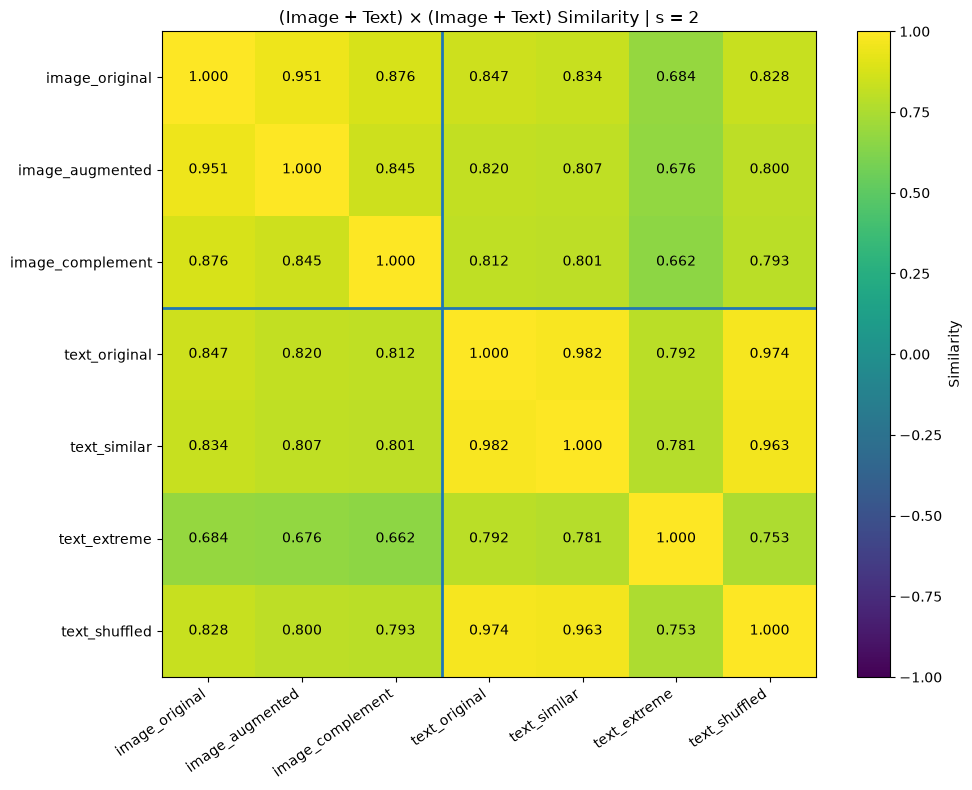

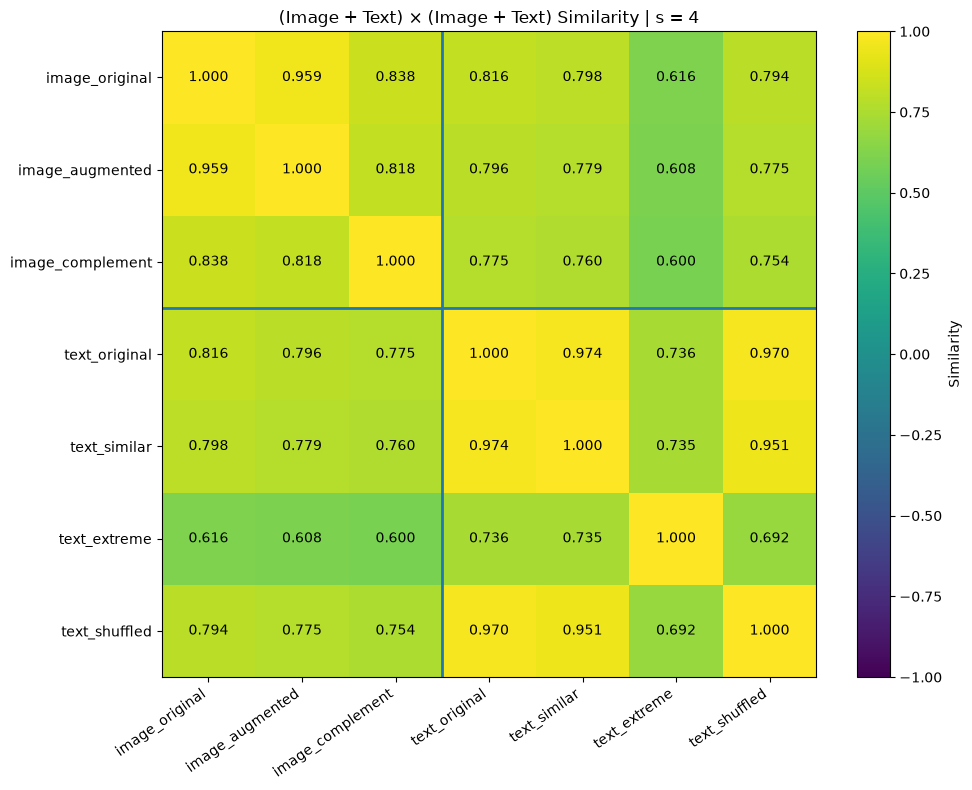

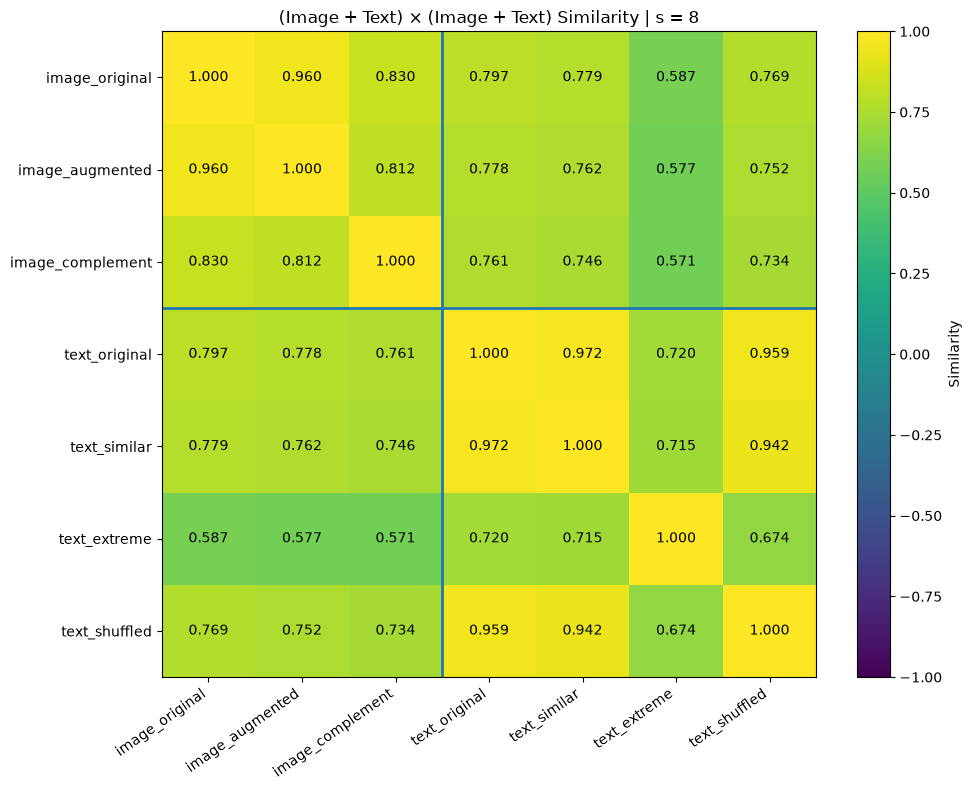

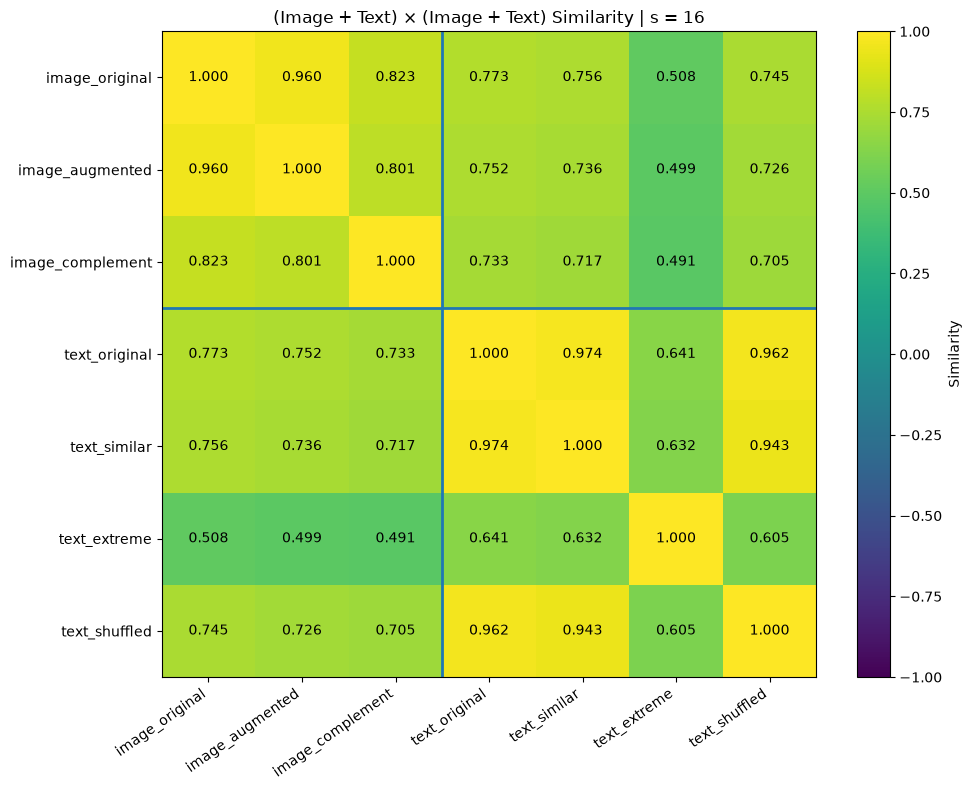

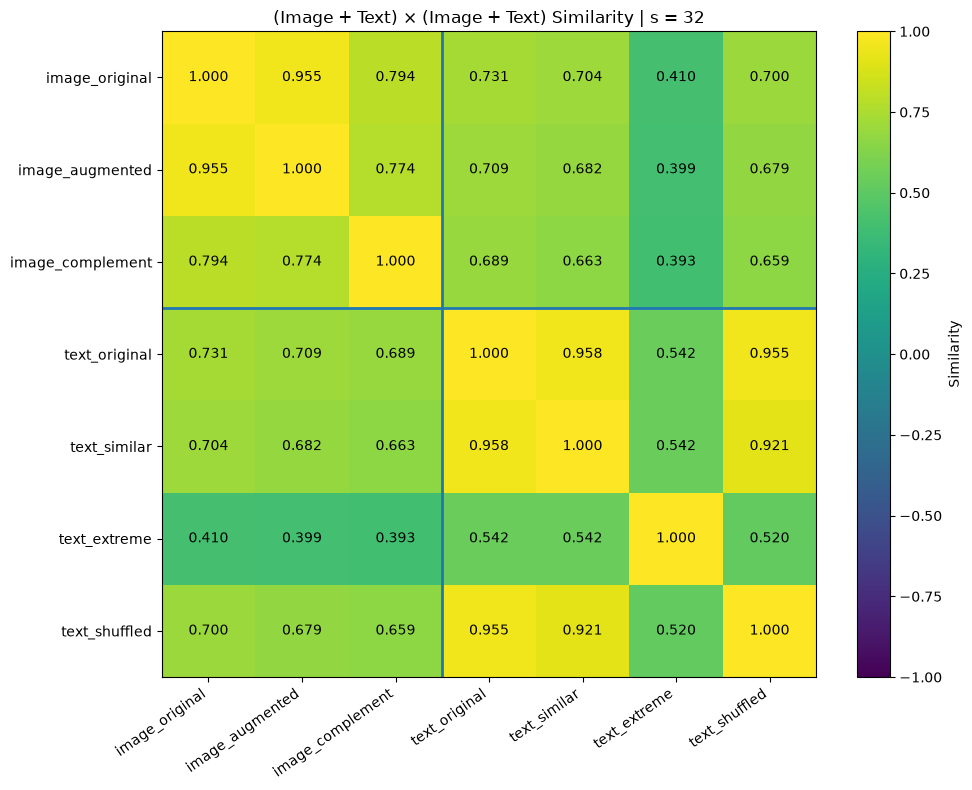

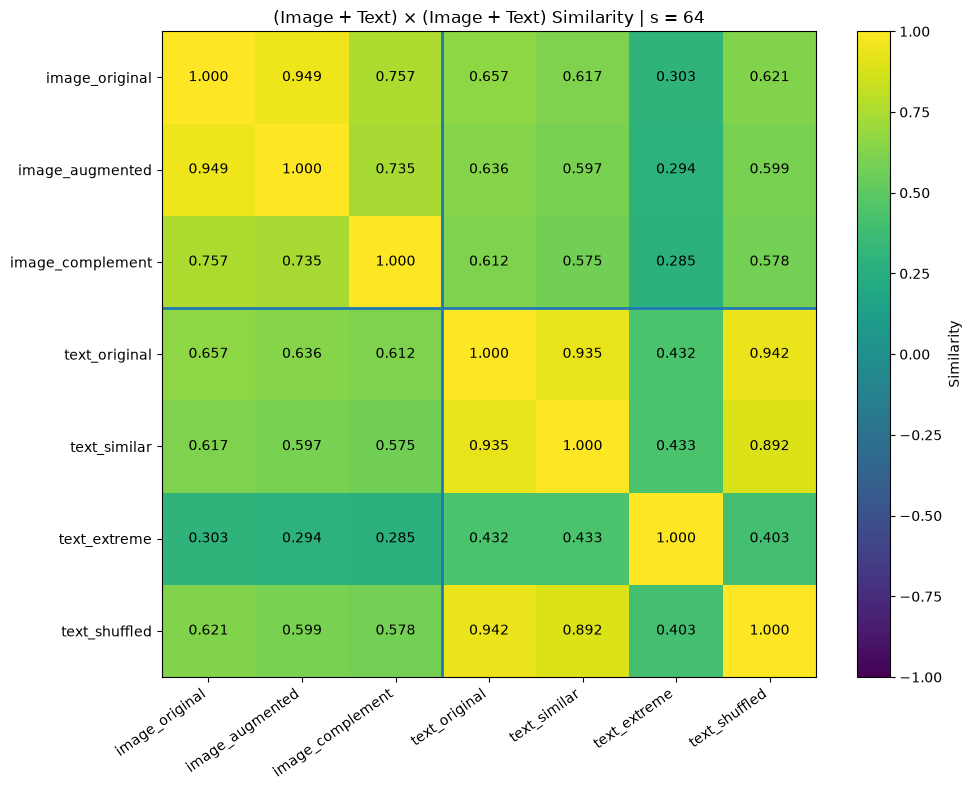

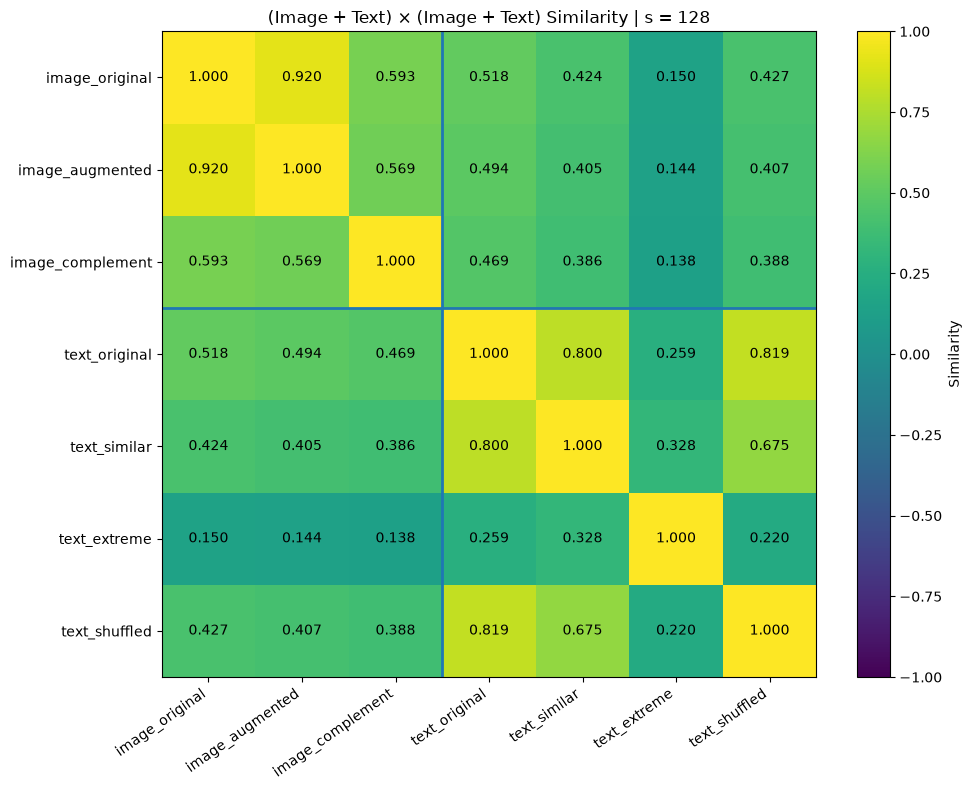

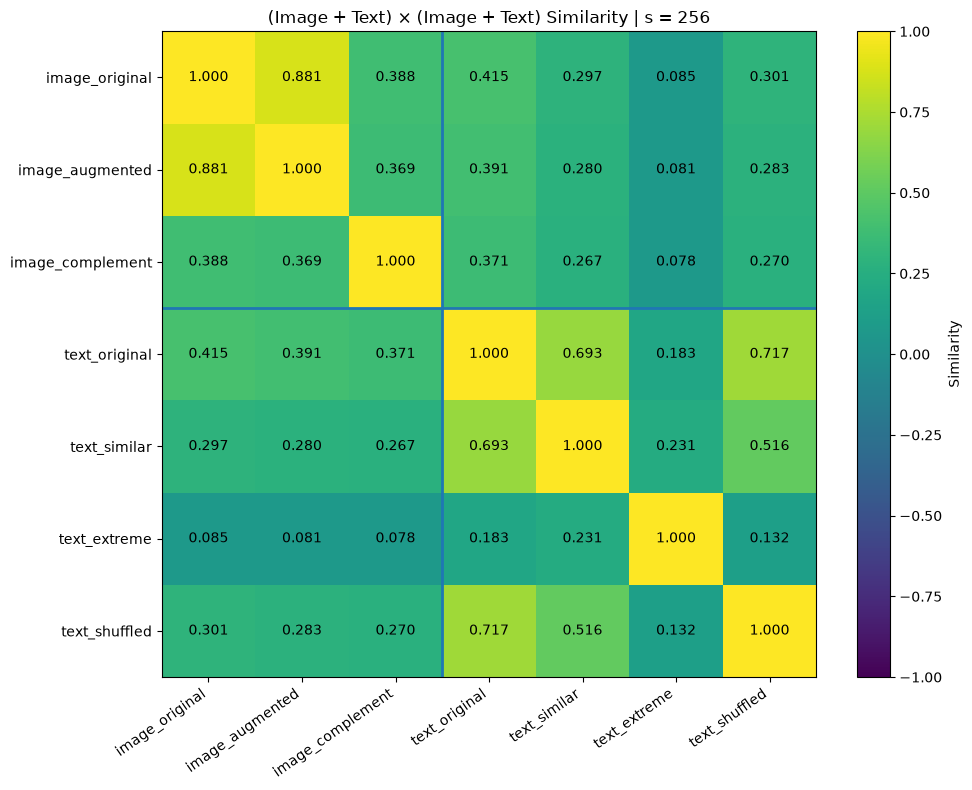

In [258]:
print("\nPositive CSA cross-similarity results:")
for s in sorted(csa_postive_results.keys()):
    plot_variant_cross_similarities(
        csa_postive_results,
        s=s
    );

In [259]:
csa_negative_results = compute_variant_cross_similarities(
    csa=csa,
    image_encoder=image_encoder,
    text_encoder=text_encoder,
    train_paths_file="train_paths.txt",
    text_original_file="train_texts.txt",
    text_sim_file="train_texts_sim.txt",
    text_extreme_file="train_texts_sim_extreme.txt",
    text_shuffled_file="train_texts_shuff.txt",
    s_values=[2, 4, 8, 16, 32, 64, 128, 256],
    max_complement_per_class=10,
    seed=SEED,
    negative=True
)


Total samples: 2000
negative=True

Encoding original images...


Encoding images | augment=False: 100%|██████████| 125/125 [00:31<00:00,  3.93it/s]



Encoding augmented images...


Encoding images | augment=True: 100%|██████████| 125/125 [00:34<00:00,  3.64it/s]



Encoding complement images...


...

Batches: 100%|██████████| 32/32 [00:00<00:00, 86.20it/s]



Encoding extreme text...


Batches: 100%|██████████| 32/32 [00:00<00:00, 61.82it/s]



Encoding shuffled text...


Batches: 100%|██████████| 32/32 [00:00<00:00, 82.74it/s]



Negative CSA cross-similarity results:


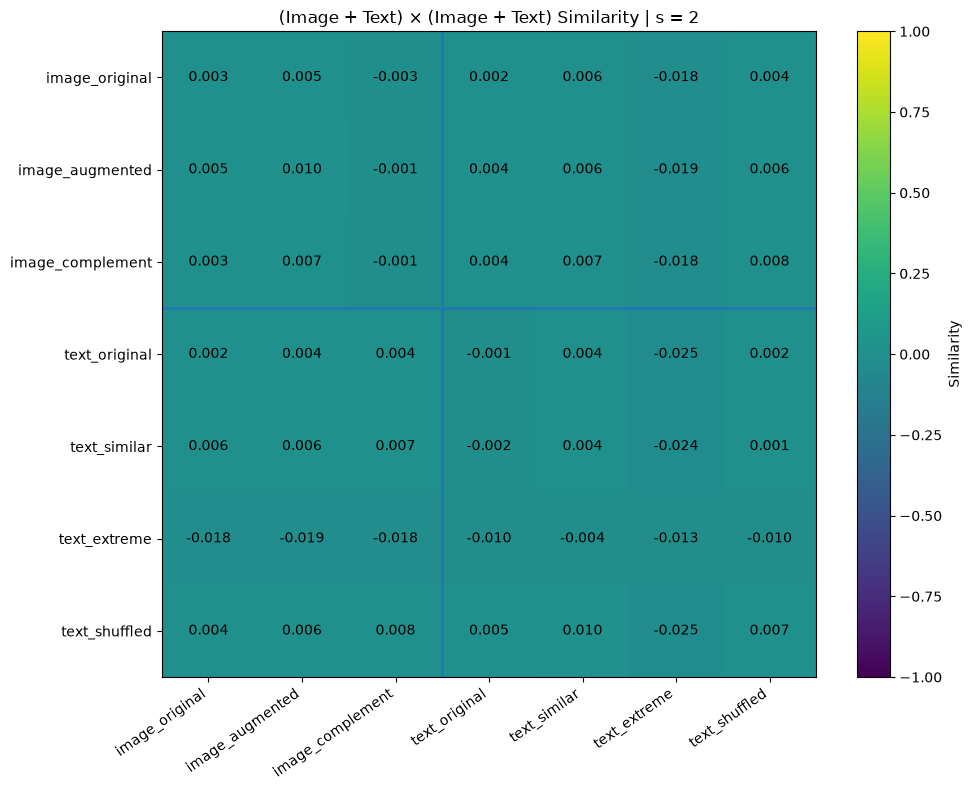

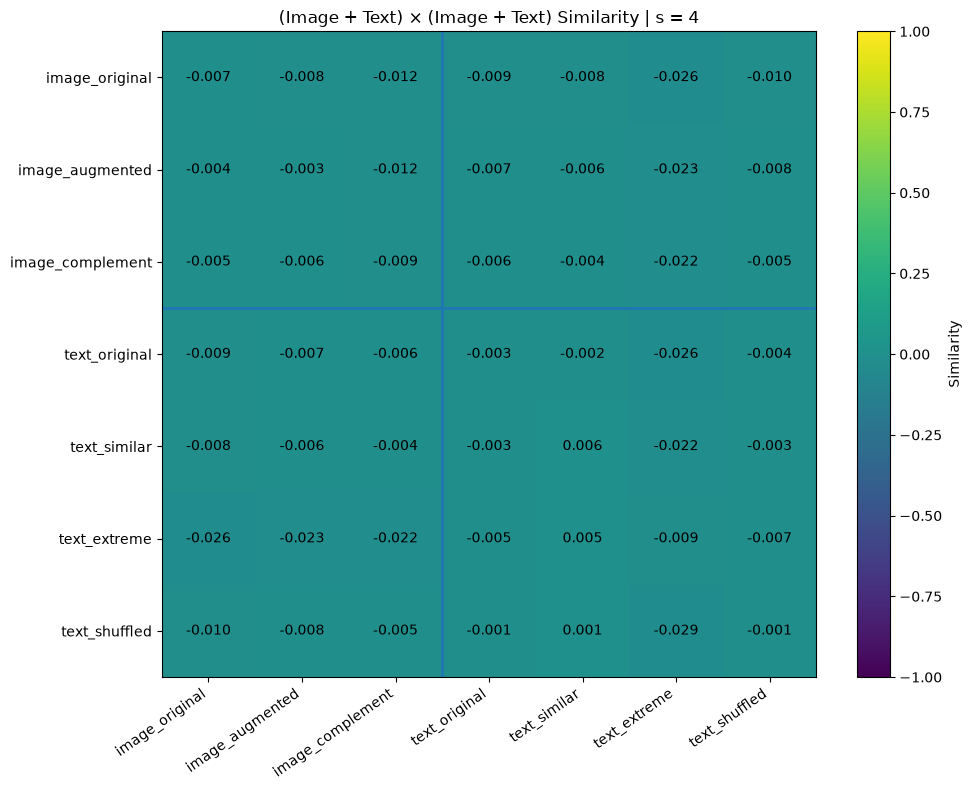

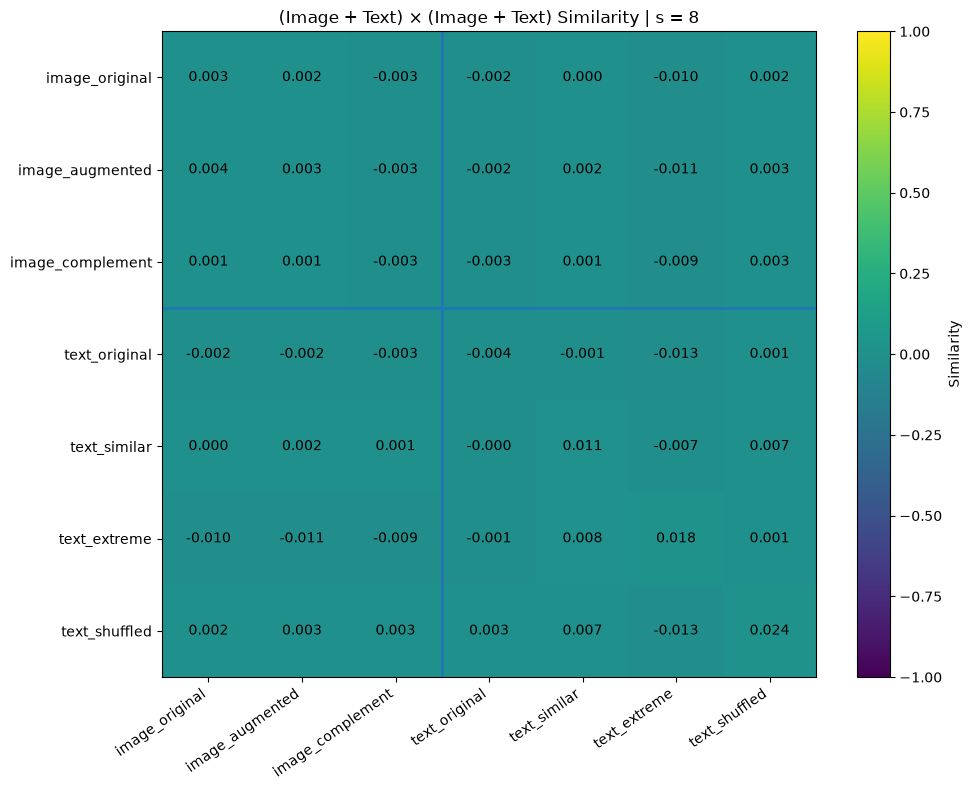

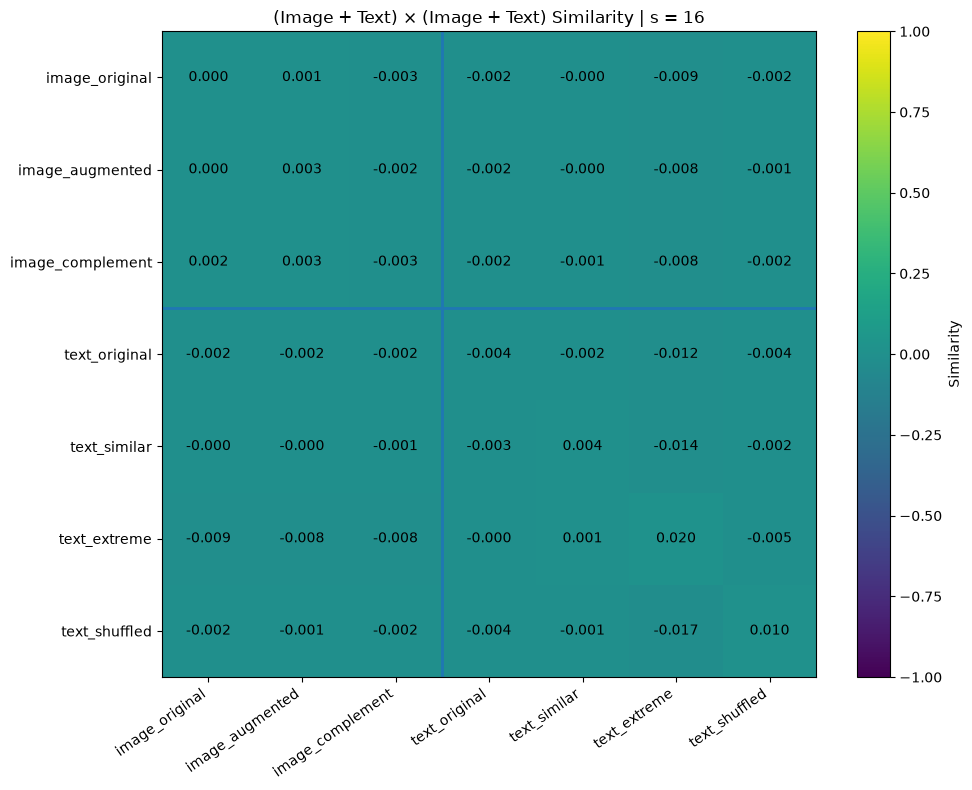

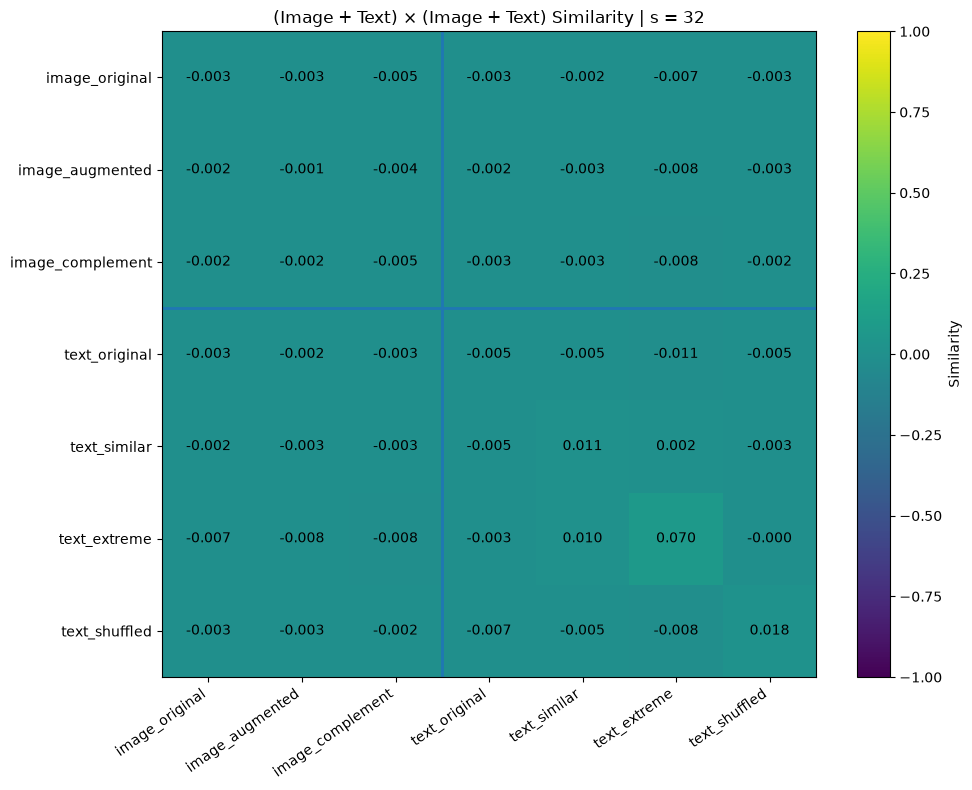

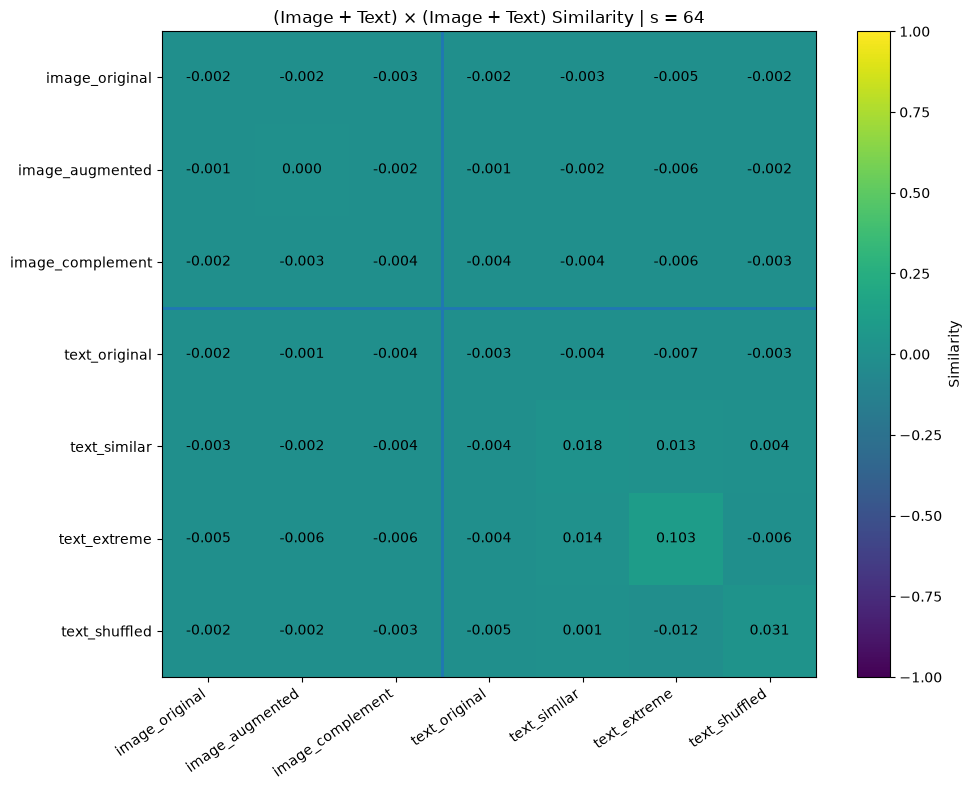

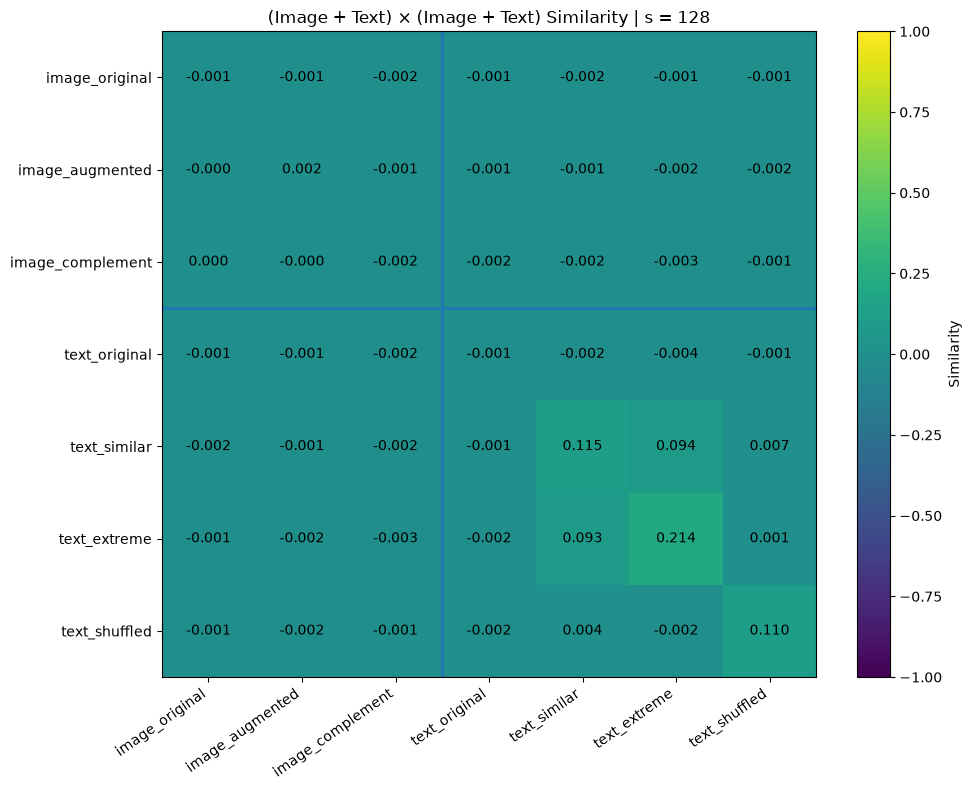

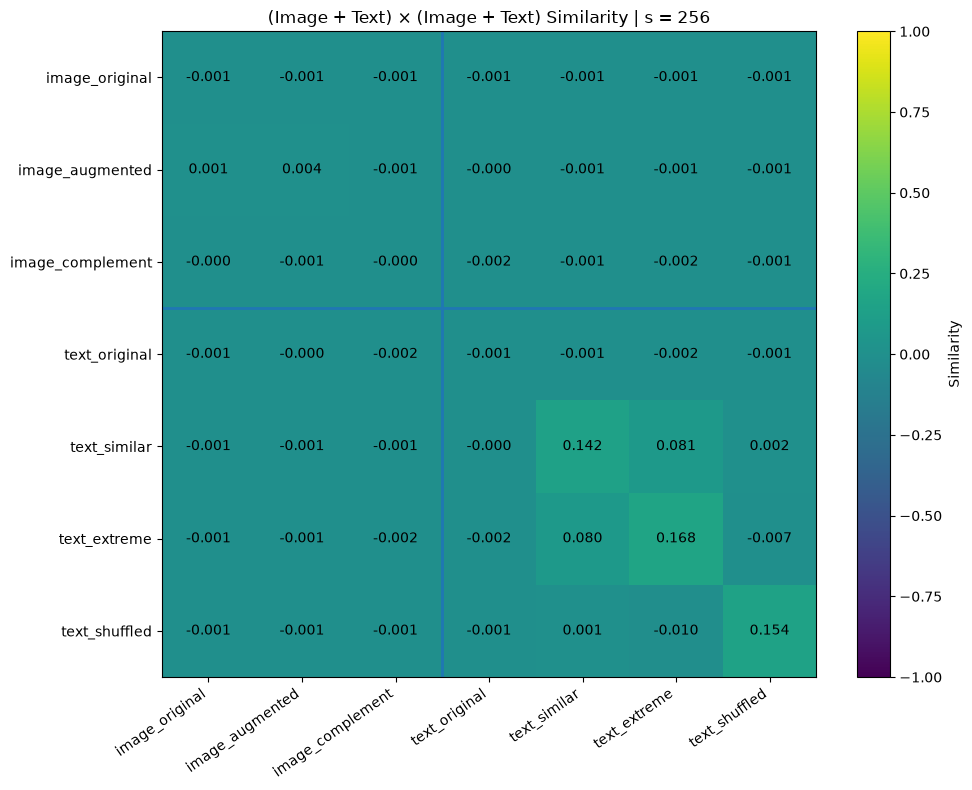

In [260]:
print("\nNegative CSA cross-similarity results:")
for s in sorted(csa_negative_results.keys()):
    plot_variant_cross_similarities(
        csa_negative_results,
        s=s
    );

## Advanced Analysis on CLIP model

In [224]:
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from transformers import CLIPModel, CLIPProcessor


class CLIPEncoder:
    def __init__(
        self,
        device,
        model_name="openai/clip-vit-base-patch32",
        batch_size=32
    ):
        self.device = device
        self.batch_size = batch_size

        self.model = CLIPModel.from_pretrained(
            model_name
        ).to(device)

        self.processor = CLIPProcessor.from_pretrained(
            model_name
        )

        self.model.eval()

        for p in self.model.parameters():
            p.requires_grad_(False)

        # PIL-level augmentation.
        # CLIPProcessor will still perform CLIP's normal preprocessing.
        self.augment_transform = transforms.Compose([
            transforms.RandomResizedCrop(
                224,
                scale=(0.8, 1.0)
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            )
        ])

    @torch.inference_mode()
    def encode_images(self, image_paths, augment=False):
        all_features = []

        for start in tqdm(
            range(0, len(image_paths), self.batch_size),
            desc=f"CLIP images | augment={augment}"
        ):
            paths = image_paths[start:start + self.batch_size]

            images = [
                Image.open(path).convert("RGB")
                for path in paths
            ]

            if augment:
                images = [
                    self.augment_transform(image)
                    for image in images
                ]

            inputs = self.processor(
                images=images,
                return_tensors="pt"
            )

            pixel_values = inputs["pixel_values"].to(self.device)

            # Vision encoder
            outputs = self.model.vision_model(
                pixel_values=pixel_values
            )

            # Pooled ViT representation
            pooled = outputs.pooler_output

            # CLIP projection into shared image-text space
            features = self.model.visual_projection(
                pooled
            )

            # L2 normalization
            features = features / features.norm(
                dim=-1,
                keepdim=True
            )

            all_features.append(
                features.cpu().numpy()
            )

        return np.concatenate(
            all_features,
            axis=0
        ).astype(np.float64)
        

    @torch.inference_mode()
    def encode_texts(self, texts):
        all_features = []

        for start in tqdm(
            range(0, len(texts), self.batch_size),
            desc="CLIP texts"
        ):
            batch_texts = texts[start:start + self.batch_size]

            inputs = self.processor(
                text=batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True
            )

            input_ids = inputs["input_ids"].to(self.device)
            attention_mask = inputs["attention_mask"].to(self.device)

            # Text encoder
            outputs = self.model.text_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # Pooled text representation
            pooled = outputs.pooler_output

            # CLIP projection into shared image-text space
            features = self.model.text_projection(
                pooled
            )

            # L2 normalization
            features = features / features.norm(
                dim=-1,
                keepdim=True
            )

            all_features.append(
                features.cpu().numpy()
            )

        return np.concatenate(
            all_features,
            axis=0
        ).astype(np.float64)

In [241]:
def compute_clip_variant_cross_similarities(
    clip_encoder,
    train_paths_file="train_paths.txt",
    text_original_file="train_texts.txt",
    text_sim_file="train_texts_sim.txt",
    text_extreme_file="train_texts_extreme.txt",
    text_shuffled_file="train_texts_shuff.txt",
    max_complement_per_class=10,
    seed=42,
    negative=False,
):
    from pathlib import Path
    from collections import defaultdict
    import random

    def load_lines(path):
        with open(path, "r", encoding="utf-8") as f:
            return [line.strip() for line in f if line.strip()]

    def derive_complement_paths(train_paths, max_per_class=10, seed=42):
        rng = random.Random(seed)
        train_by_class = defaultdict(list)

        for path in train_paths:
            p = Path(path)
            train_by_class[p.parent.name].append(p)

        complement_by_class = {}
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}

        for class_name, class_train_paths in train_by_class.items():
            class_dir = class_train_paths[0].parent
            train_set = {p.resolve() for p in class_train_paths}

            candidates = [
                p for p in sorted(class_dir.iterdir())
                if (
                    p.is_file()
                    and p.suffix.lower() in valid_exts
                    and p.resolve() not in train_set
                )
            ]

            if len(candidates) == 0:
                raise ValueError(
                    f"No complement images for class: {class_name}"
                )

            rng.shuffle(candidates)
            complement_by_class[class_name] = candidates[:max_per_class]

        counters = defaultdict(int)
        complement_paths = []

        for path in train_paths:
            p = Path(path)
            class_name = p.parent.name
            candidates = complement_by_class[class_name]

            idx = counters[class_name] % len(candidates)
            complement_paths.append(str(candidates[idx]))
            counters[class_name] += 1

        return complement_paths

    def paired_cosine(X, Y):
        X = X / np.clip(
            np.linalg.norm(X, axis=1, keepdims=True),
            1e-12,
            None
        )

        Y = Y / np.clip(
            np.linalg.norm(Y, axis=1, keepdims=True),
            1e-12,
            None
        )

        return np.sum(X * Y, axis=1)

    train_paths = load_lines(train_paths_file)
    texts_original = load_lines(text_original_file)
    texts_similar = load_lines(text_sim_file)
    texts_extreme = load_lines(text_extreme_file)
    texts_shuffled = load_lines(text_shuffled_file)

    N = len(train_paths)

    complement_paths = derive_complement_paths(
        train_paths,
        max_per_class=max_complement_per_class,
        seed=seed
    )

    print(f"\nTotal samples: {N}")
    print(f"negative={negative}")

    img_original = clip_encoder.encode_images(
        train_paths,
        augment=False
    )

    img_augmented = clip_encoder.encode_images(
        train_paths,
        augment=True
    )

    img_complement = clip_encoder.encode_images(
        complement_paths,
        augment=False
    )

    txt_original = clip_encoder.encode_texts(texts_original)
    txt_similar = clip_encoder.encode_texts(texts_similar)
    txt_extreme = clip_encoder.encode_texts(texts_extreme)
    txt_shuffled = clip_encoder.encode_texts(texts_shuffled)

    variants = {
        "image_original": img_original,
        "image_augmented": img_augmented,
        "image_complement": img_complement,

        "text_original": txt_original,
        "text_similar": txt_similar,
        "text_extreme": txt_extreme,
        "text_shuffled": txt_shuffled,
    }

    labels = list(variants.keys())

    rng = np.random.default_rng(seed)
    permutation = rng.permutation(N)

    if negative and np.any(permutation == np.arange(N)):
        permutation = np.roll(permutation, 1)

    similarity_matrix = np.zeros(
        (len(labels), len(labels)),
        dtype=np.float64
    )

    raw_scores = {}

    for i, name1 in enumerate(labels):
        for j, name2 in enumerate(labels):
            X = variants[name1]

            Y = (
                variants[name2][permutation]
                if negative
                else variants[name2]
            )

            scores = paired_cosine(X, Y)

            similarity_matrix[i, j] = scores.mean()
            raw_scores[(name1, name2)] = scores

    image_labels = [
        "image_original",
        "image_augmented",
        "image_complement",
    ]

    text_labels = [
        "text_original",
        "text_similar",
        "text_extreme",
        "text_shuffled",
    ]

    return {
        "matrix": similarity_matrix,
        "labels": labels,

        "image_cosine_matrix":
            similarity_matrix[:3, :3],

        "cross_modal_matrix":
            similarity_matrix[:3, 3:],

        "text_cosine_matrix":
            similarity_matrix[3:, 3:],

        "image_labels": image_labels,
        "text_labels": text_labels,

        "raw": raw_scores,

        "negative": negative,
        "permutation": permutation.copy(),

        "train_paths": train_paths,
        "complement_paths": complement_paths,
    }

In [242]:
def plot_clip_variant_cross_similarities(clip_results):
    matrix = clip_results["matrix"]
    labels = clip_results["labels"]

    plt.figure(figsize=(10, 8))

    im = plt.imshow(
        matrix,
        aspect="auto",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(
        im,
        label="CLIP Cosine Similarity"
    )

    plt.xticks(
        np.arange(len(labels)),
        labels,
        rotation=35,
        ha="right"
    )

    plt.yticks(
        np.arange(len(labels)),
        labels
    )

    # Values inside cells
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(
                j,
                i,
                f"{matrix[i, j]:.3f}",
                ha="center",
                va="center"
            )

    # Separate image and text blocks
    n_images = len(
        clip_results["image_labels"]
    )

    plt.axhline(
        n_images - 0.5,
        linewidth=2
    )

    plt.axvline(
        n_images - 0.5,
        linewidth=2
    )

    plt.title(
        "CLIP (Image + Text) × (Image + Text) Similarity"
    )

    plt.tight_layout()
    plt.show()

    return matrix

In [243]:
device = get_device()

clip_encoder = CLIPEncoder(
    device=device,
    model_name="openai/clip-vit-base-patch32",
    batch_size=32
)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 53312.88it/s]


In [244]:
clip_positive_results = compute_clip_variant_cross_similarities(
    clip_encoder=clip_encoder,

    train_paths_file="train_paths.txt",

    text_original_file="train_texts.txt",
    text_sim_file="train_texts_sim.txt",
    text_extreme_file="train_texts_sim_extreme.txt",
    text_shuffled_file="train_texts_shuff.txt",

    max_complement_per_class=10,
    seed=SEED,
    negative=False
)


Total samples: 2000
negative=False


CLIP images | augment=False: 100%|██████████| 63/63 [00:13<00:00,  4.56it/s]
CLIP images | augment=True: 100%|██████████| 63/63 [00:12<00:00,  4.90it/s]
CLIP images | augment=False: 100%|██████████| 63/63 [00:11<00:00,  5.64it/s]
CLIP texts: 100%|██████████| 63/63 [00:01<00:00, 52.37it/s]


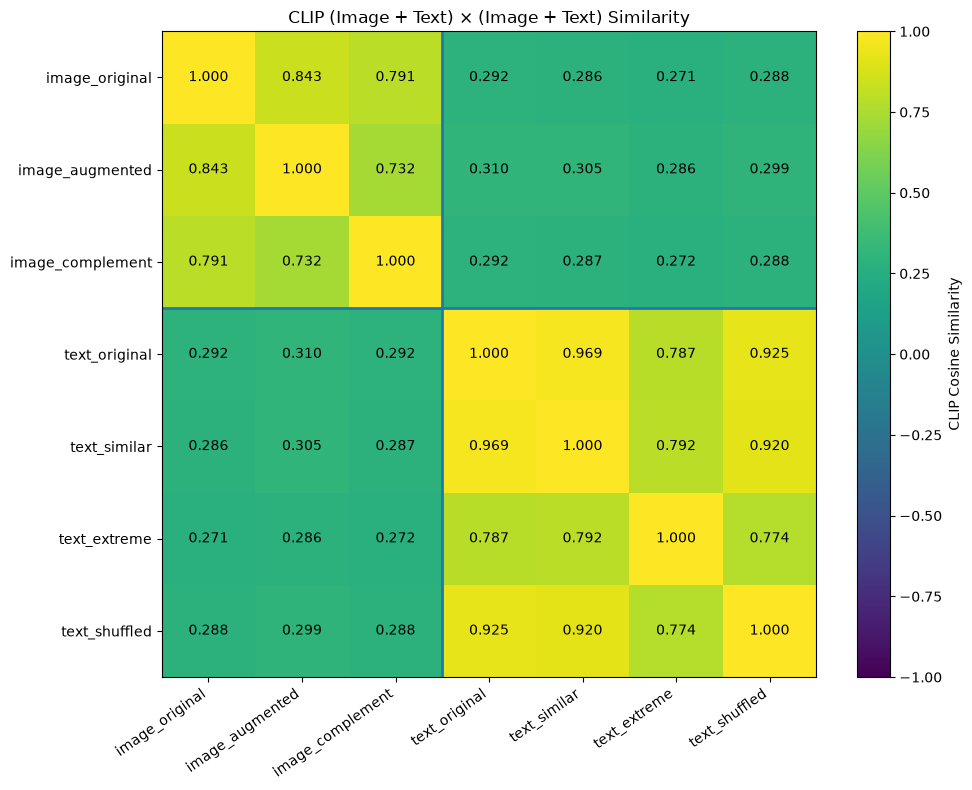

In [ ]:
print("\nCLIP positive cross-similarity results:")
plot_clip_variant_cross_similarities(clip_positive_results);

In [245]:
clip_negative_results = compute_clip_variant_cross_similarities(
    clip_encoder=clip_encoder,

    train_paths_file="train_paths.txt",

    text_original_file="train_texts.txt",
    text_sim_file="train_texts_sim.txt",
    text_extreme_file="train_texts_sim_extreme.txt",
    text_shuffled_file="train_texts_shuff.txt",

    max_complement_per_class=10,
    seed=SEED,
    negative=True
)


Total samples: 2000
negative=True


CLIP images | augment=False: 100%|██████████| 63/63 [00:11<00:00,  5.31it/s]
CLIP images | augment=True: 100%|██████████| 63/63 [00:13<00:00,  4.59it/s]
CLIP images | augment=False: 100%|██████████| 63/63 [00:10<00:00,  5.75it/s]
CLIP texts: 100%|██████████| 63/63 [00:01<00:00, 52.85it/s]



CLIP negative cross-similarity results:


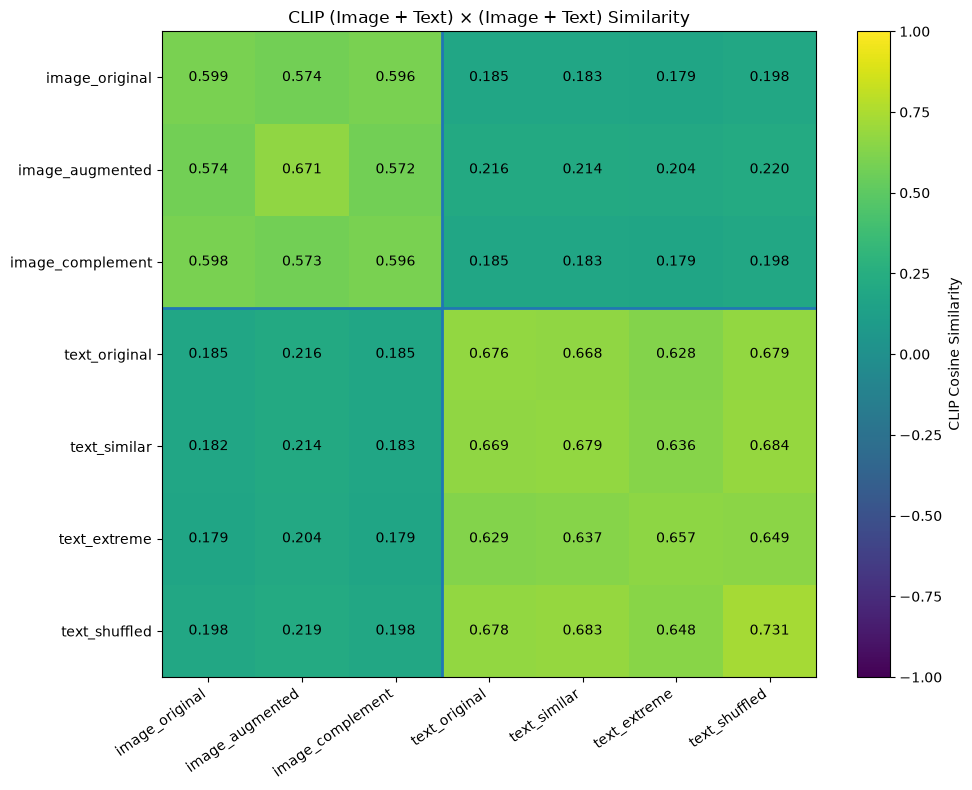

In [246]:
print("\nCLIP negative cross-similarity results:")
plot_clip_variant_cross_similarities(clip_negative_results);